In [1]:

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from scipy import stats
from functools import reduce
%matplotlib inline
matplotlib.style.use("ggplot")


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        f_name=os.path.join(dirname,filename)



/kaggle/input/hranalytics/WA_Fn-UseC_-HR-Employee-Attrition.csv


# HR analytics


In [2]:
data=pd.read_csv(f_name)


In [3]:
# Check for missings
print(np.count_nonzero(data.isnull().values))

0


In [4]:
# Check for duplicates
print(data[data.duplicated(keep=False)].shape)

(0, 35)


# Show first ten element 


In [5]:
data.head(10)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


# Show numbers of rows and columns 


In [6]:
data.shape[0] # rows

1470

In [7]:
data.shape[1] #columns

35

# Now I want to see features of my data and their types 

In [8]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

# Classification numerical and categorical data
- Numerica features

In [9]:
numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
data[numeric_cols].head() 

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1102,1,2,1,1,2,94,3,2,...,1,80,0,8,0,1,6,4,0,5
1,49,279,8,1,1,2,3,61,2,2,...,4,80,1,10,3,3,10,7,1,7
2,37,1373,2,2,1,4,4,92,2,1,...,2,80,0,7,3,3,0,0,0,0
3,33,1392,3,4,1,5,4,56,3,1,...,3,80,0,8,3,3,8,7,3,0
4,27,591,2,1,1,7,1,40,3,1,...,4,80,1,6,3,3,2,2,2,2


- Categorical feautres

# Descriptive statistics 

In [10]:
data.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


# Exploratory Data Analysis


In [11]:
data['Attrition'].value_counts()


No     1233
Yes     237
Name: Attrition, dtype: int64

<AxesSubplot:ylabel='Attrition'>

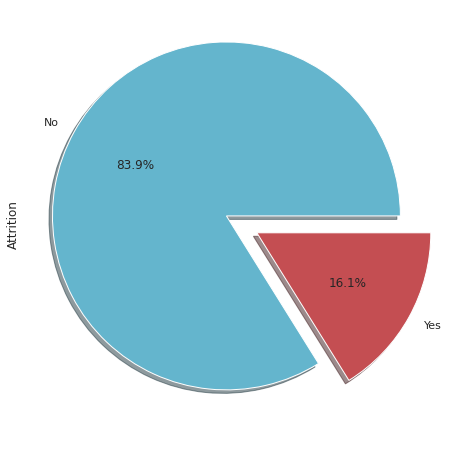

In [12]:
plt.figure(figsize=(20,8))
sns.set(style='whitegrid')
data['Attrition'].value_counts().plot(kind='pie',explode=[0.1,0.1],autopct='%1.1f%%',shadow=True,colors=['c','r'])


**That is meaning that the employees they leave equal 273**

In [13]:
data['Gender'].value_counts()

Male      882
Female    588
Name: Gender, dtype: int64

In [14]:
data['JobRole'].value_counts()

Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: JobRole, dtype: int64

In [15]:
data['BusinessTravel'].value_counts()

Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: BusinessTravel, dtype: int64

([<matplotlib.patches.Wedge at 0x7f4871bd3590>,
 [Text(1.613394764032677, 0.5356839883662224, 'Non-Travel '),
  Text(0.5797530415259028, 1.6511772802583815, 'Travel_Frequently'),
  Text(-1.0705175339438622, -1.384374302534814, 'Travel_Rarely')],
 [Text(0.9016029563712016, 0.299352817028183, '10.2%'),
  Text(0.3312874523005158, 0.9435298744333607, '18.8%'),
  Text(-0.6117243051107781, -0.7910710300198935, '71.0%')])

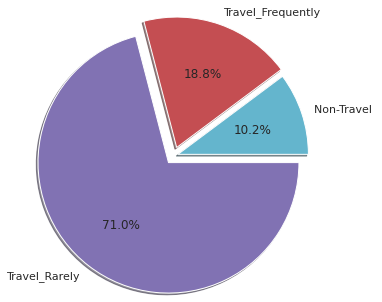

In [16]:
r = data.groupby('BusinessTravel')['BusinessTravel'].count()
plt.pie(r, explode=[0.05, 0.1,0.1], labels=['Non-Travel ', 'Travel_Frequently','Travel_Rarely'], radius=1.5, autopct='%1.1f%%',  shadow=True,colors=['c','r','m'])

In [17]:
data['Department'].value_counts()


Research & Development    961
Sales                     446
Human Resources            63
Name: Department, dtype: int64

# Correlation between features 

<AxesSubplot:>

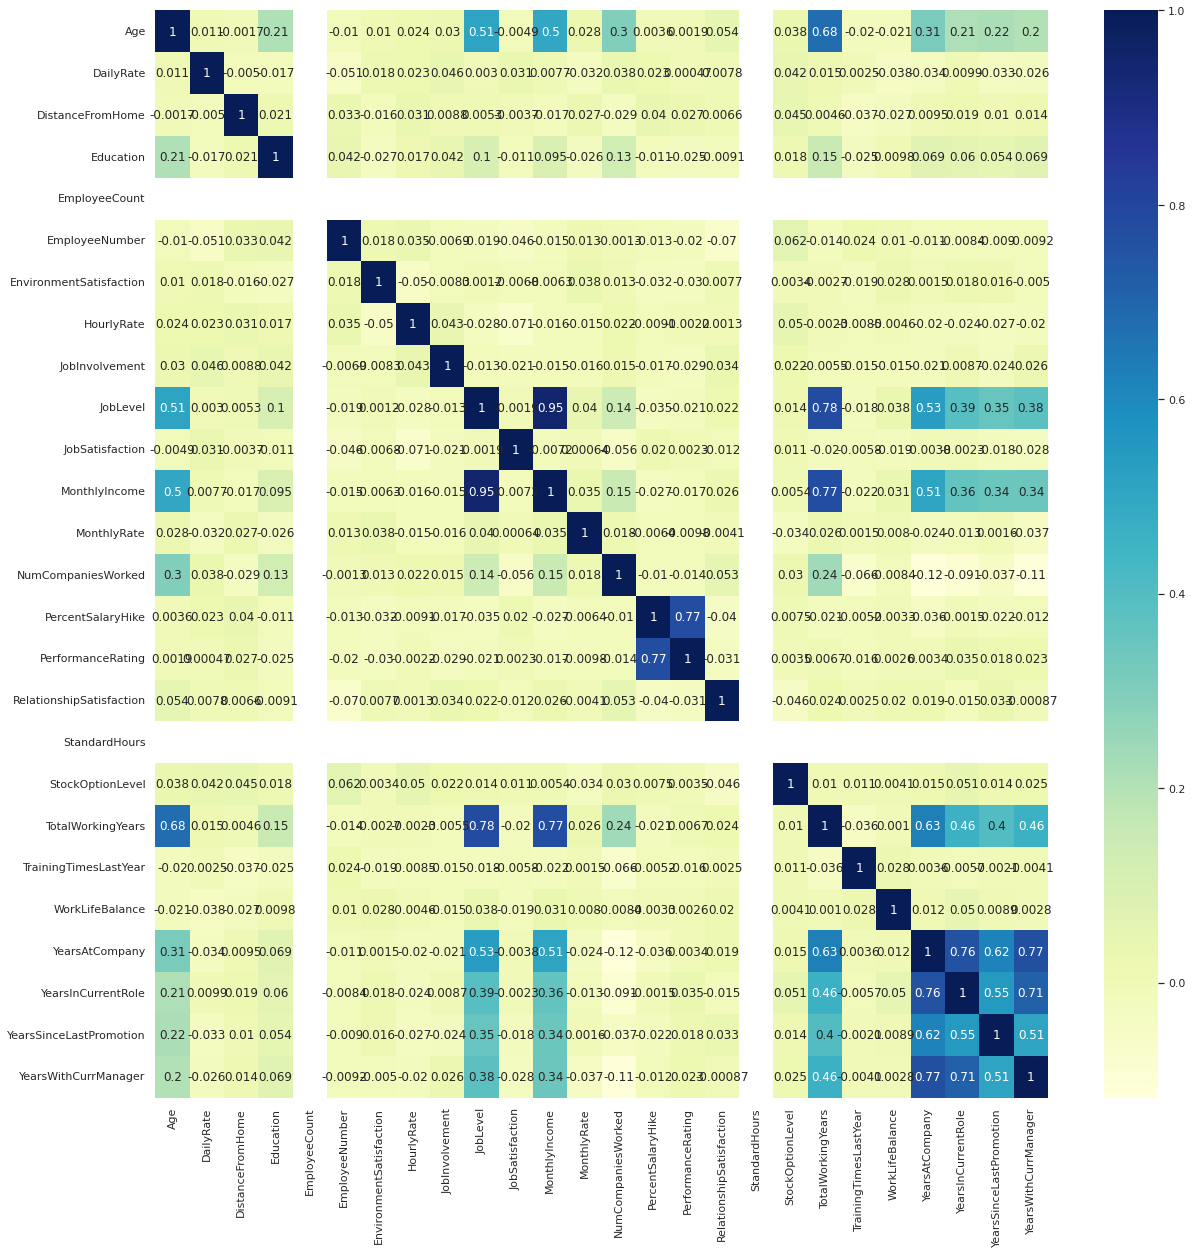

In [18]:
plt.figure(figsize=(20,20))
sns.heatmap(data.corr(), annot=True, cmap="YlGnBu")

# Who get more salary?
   ### Female more than Male

<AxesSubplot:title={'center':'Average Monthly Income by Gender'}, xlabel='Gender', ylabel='MonthlyIncome'>

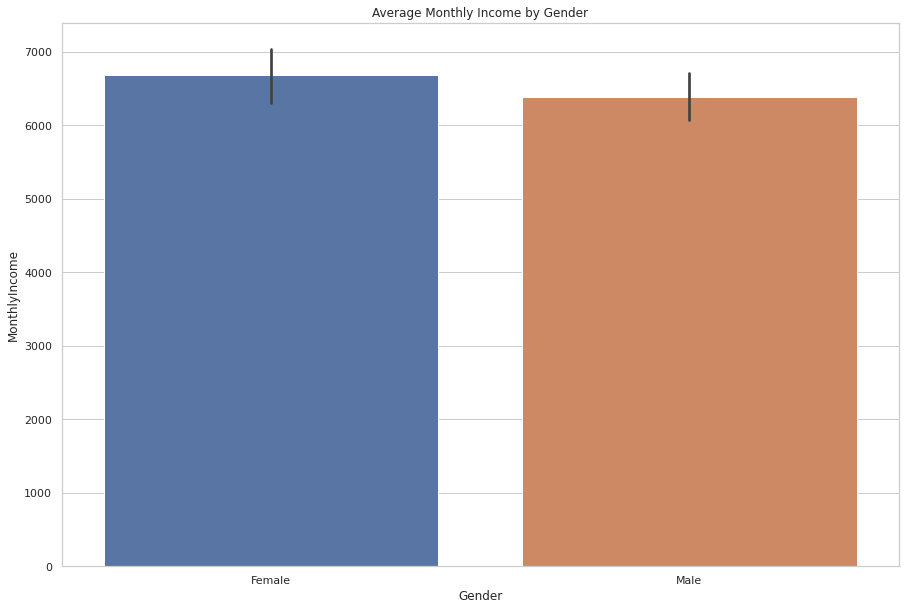

In [19]:
plt.figure(figsize=(15,10))
plt.title('Average Monthly Income by Gender')
sns.barplot(x="Gender", y="MonthlyIncome", data=data)

### Relationship between salary and age

<AxesSubplot:title={'center':'Average Monthly Income by Age'}, xlabel='Age', ylabel='MonthlyIncome'>

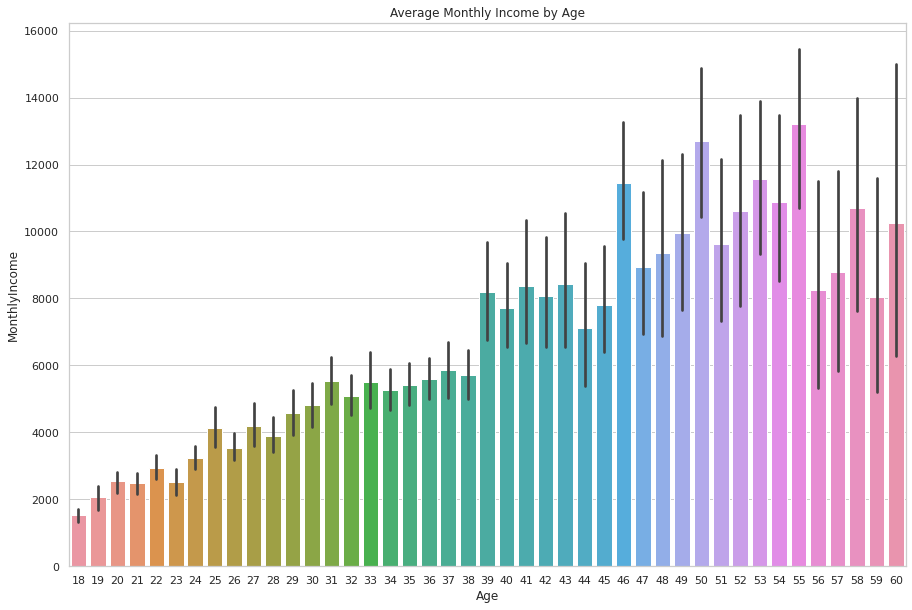

In [20]:
plt.figure(figsize=(15,10))
plt.title('Average Monthly Income by Age')
sns.barplot(x="Age", y="MonthlyIncome", data=data)


### Employees have more jobinvolvement not has more salay 

<AxesSubplot:title={'center':'Average Monthly Income by Age'}, xlabel='JobInvolvement', ylabel='MonthlyIncome'>

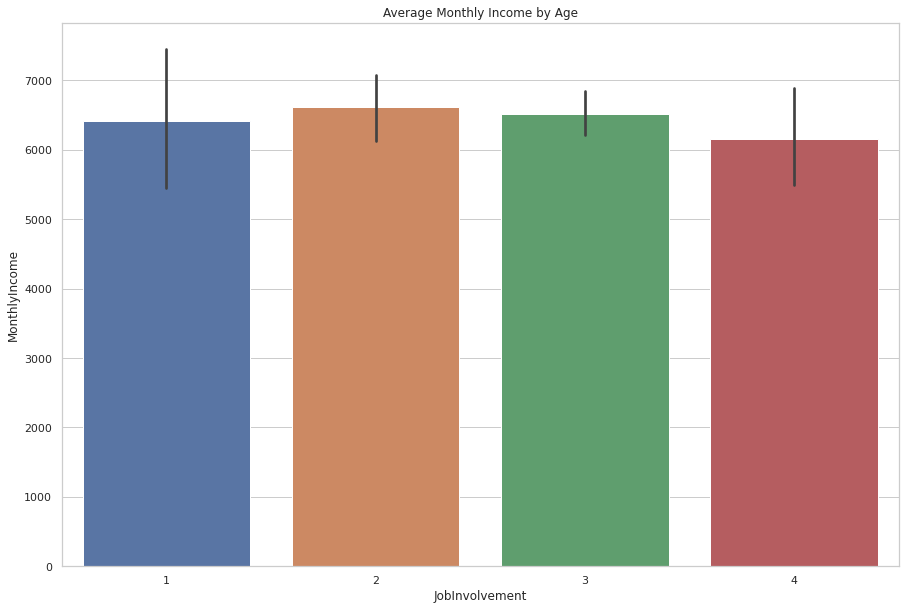

In [21]:
plt.figure(figsize=(15,10))
plt.title('Average Monthly Income by Age')
sns.barplot(x="JobInvolvement", y="MonthlyIncome", data=data)

### High level eduation more salary .. It's fair

<AxesSubplot:title={'center':'Average Monthly Income by Age'}, xlabel='Education', ylabel='MonthlyIncome'>

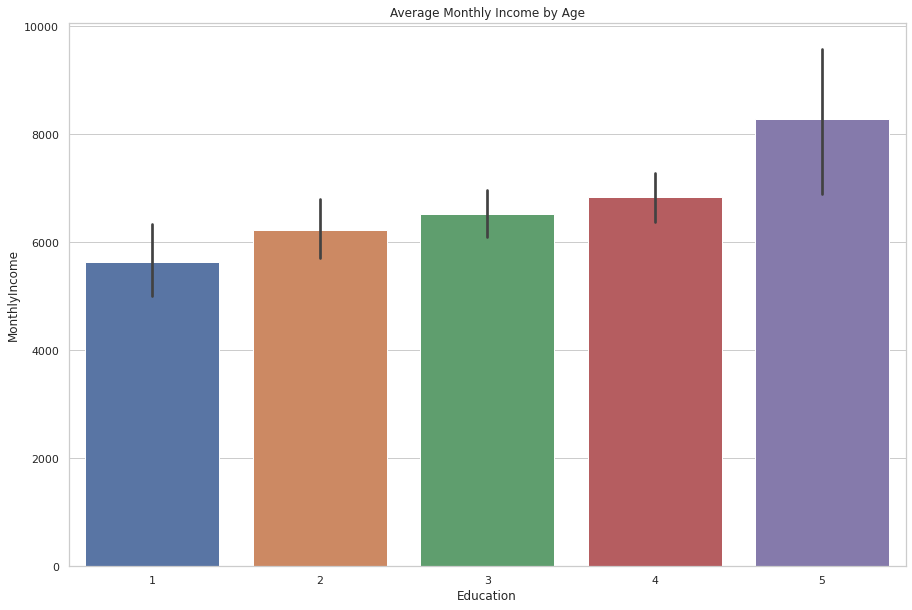

In [22]:
plt.figure(figsize=(15,10))
plt.title('Average Monthly Income by Age')
sns.barplot(x="Education", y="MonthlyIncome", data=data)

# What are the reasons to leaving an employee?

- ### The most employees leavs in their early 30's.. Maybe has trouble retaining young employees? or starting salary is not enough

/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


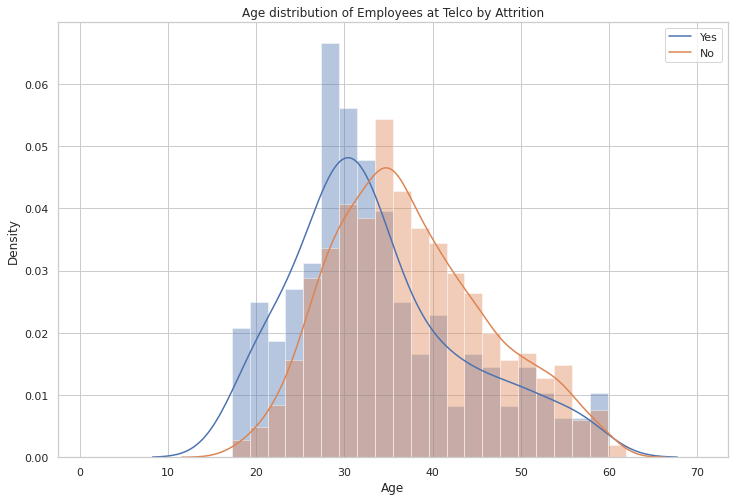

In [23]:
# Plot the distribution of age by Attrition Factor
plt.figure(figsize=(12,8))
plt.title('Age distribution of Employees at Telco by Attrition')
sns.distplot(data.Age[data.Attrition == 'Yes'], bins = np.linspace(1,70,35))
sns.distplot(data.Age[data.Attrition == 'No'], bins = np.linspace(1,70,35))
plt.legend(['Yes','No'])

- ### Sales Representative and Lab Technicians have higher attrition rate.


In [24]:
pd.crosstab([data['Attrition']],data['JobRole'],normalize=True)*100


JobRole,Healthcare Representative,Human Resources,Laboratory Technician,Manager,Manufacturing Director,Research Director,Research Scientist,Sales Executive,Sales Representative
Attrition,,,,,,,,,
No,8.299320,2.721088,13.401361,6.598639,9.183673,5.306122,16.666667,18.299320,3.401361
Yes,0.612245,0.816327,4.217687,0.340136,0.680272,0.136054,3.197279,3.877551,2.244898


/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


Text(0.5, 1.0, 'Attrition amongst different JobRoles')

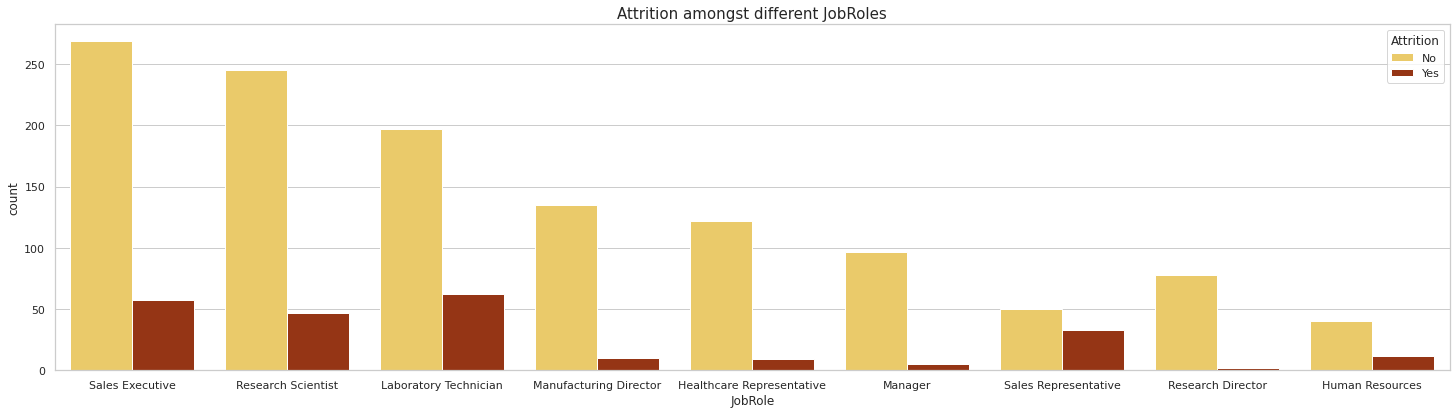

In [25]:
plt.figure(figsize=(25,14))
sns.set(style="whitegrid")
plt.subplot(211)
plt.title('JobRole Vs Attrition')
sns.countplot(data['JobRole'],palette='afmhot_r',hue=data['Attrition'].sort_values(ascending=True))
plt.title('Attrition amongst different JobRoles',size=15)

- ### Why? 

### They have minimum salary

In [26]:
pd.pivot_table(data=data,index=['JobRole'],values=['MonthlyIncome'],aggfunc='mean').sort_values(by='MonthlyIncome').style.set_properties(**{'background-color': 'black',
                                                                                                               'color': 'lawngreen',
                                                                                                               })

,MonthlyIncome
JobRole,
Sales Representative,2626.000000
Laboratory Technician,3237.169884
Research Scientist,3239.972603
Human Resources,4235.750000
Sales Executive,6924.279141
Manufacturing Director,7295.137931
Healthcare Representative,7528.763359
Research Director,16033.550000
Manager,17181.676471


- ### There is strong relationship between JobInvolvement  and atrrition ..maybe employees has more jobinvlvement The company does not want them to leave

Attrition        No  Yes
JobInvolvement          
1                55   28
2               304   71
3               743  125
4               131   13


/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


<AxesSubplot:title={'center':'JobInvolvement Vs Attrition'}, xlabel='JobInvolvement', ylabel='count'>

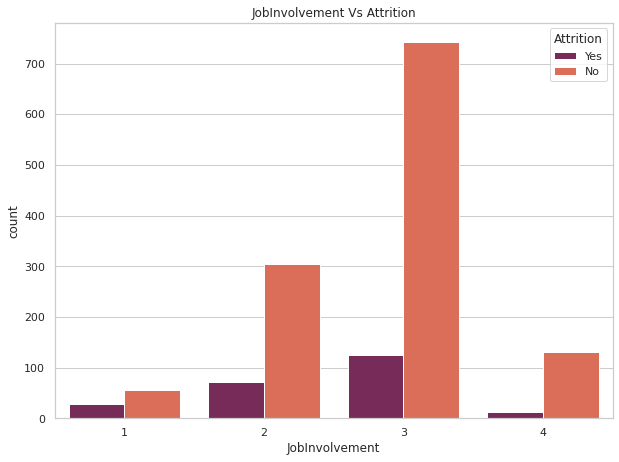

In [27]:
print(pd.crosstab(data['JobInvolvement'],data['Attrition']))
plt.figure(figsize=(22,16))
plt.subplot(221)
plt.title('JobInvolvement Vs Attrition')
sns.countplot(data['JobInvolvement'],hue=data['Attrition'],palette='rocket')
